In [50]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns 

In [51]:
args = {'width': 540,
          'height': 380,
          'firework': 'videos/firework.mp4',
          'default': 'videos/video5sec.mp4',
          'image_folder': os.path.join(os.getcwd(), 'images')}

VIDEO PROCESSING

In [52]:
cap = cv2.VideoCapture(args['firework'])
length = cap.get(cv2.CAP_PROP_FRAME_COUNT)

video_frames = []
while (cap.isOpened()):

    ret, frame = cap.read()

    if not ret:
        print('Can\'t receive frame (or stream end).')
        break

    frame = cv2.resize(frame, (args['width'], args['height']), fx=0, fy=0, interpolation=cv2.INTER_CUBIC)
    video_frames.append(frame)

video_frames = np.array(video_frames)

print(f'Frames: {video_frames.shape[0]} \nWidth: {video_frames.shape[2]} \nHeight: {video_frames.shape[1]}')
cap.release()

Can't receive frame (or stream end).
Frames: 263 
Width: 540 
Height: 380


### IMAGES PROCESSING

RGB2GRAY

In [53]:
gray_video_frames = []

for frame in video_frames:
    # from RGB to GRAY (0-255)  
    gray_video_frames.append(cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY))

gray_video_frames = np.array(gray_video_frames)

print(f'Frames: {gray_video_frames.shape[0]} \nWidth: {gray_video_frames.shape[2]} \nHeight: {gray_video_frames.shape[1]}')

Frames: 263 
Width: 540 
Height: 380


RGB2HSV

In [54]:
hsv_video_frames = []

for frame in video_frames:
    # from RGB to GRAY (0-255)  
    hsv_video_frames.append(cv2.cvtColor(frame, cv2.COLOR_RGB2HSV))

hsv_video_frames = np.array(hsv_video_frames)

print(f'Frames: {hsv_video_frames.shape[0]} \nWidth: {hsv_video_frames.shape[2]} \nHeight: {hsv_video_frames.shape[1]}')

Frames: 263 
Width: 540 
Height: 380


Example of the image

In [55]:
cv2.imshow('150\'s frame', gray_video_frames[150])
cv2.waitKey()
cv2.destroyAllWindows()

### Contrasting Areas

With Blur Code

In [60]:
for i in range(150, 200, 200):
    img = gray_video_frames[i]
    img = cv2.GaussianBlur(img, (3, 3), 0)
    img = cv2.Laplacian(img, cv2.CV_16S, ksize=3)
    img_blur = cv2.convertScaleAbs(img)

    img_blur = np.array(img_blur)
    print(f'Pixels blur from 220 to 255: {((img_blur > 220) & (img_blur <= 255)).sum()}')

    ret, img_blur_threshold = cv2.threshold(img_blur, 127, 255, cv2.THRESH_BINARY)

    print(f'Pixels in 255: {(img_blur_threshold == 255).sum()}')

# cv2.imshow(f'frame{i}_blur', img_blur)
# cv2.imshow(f'frame{i}_with_threshold', img_blur_threshold)
cv2.waitKey()
cv2.destroyAllWindows()

Pixels blur from 220 to 255: 1041
Pixels in 255: 4492


Without Blur Code

In [61]:
for i in range(150, 200, 200):
    img = gray_video_frames[i]

    img_without_blur = cv2.Laplacian(img, cv2.CV_16S, ksize=3)

    img_without_blur = cv2.convertScaleAbs(img_without_blur)


    img_without_blur = np.array(img_without_blur)
    print(f'Pixels from 220 to 255: {((img_without_blur > 220) & (img_without_blur <= 255)).sum()}')

    ret, img_without_blur_threshold = cv2.threshold(img_without_blur, 127, 255, cv2.THRESH_BINARY)


    img_without_blur_threshold = np.array(img_without_blur_threshold)
    print(f'Pixels in 255: {(img_without_blur_threshold == 255).sum()}')

# cv2.imshow(f'frame{i}_without', img_without_blur)
# cv2.imshow(f'frame{i}_without_threshold', img_without_blur_threshold)
cv2.waitKey()
cv2.destroyAllWindows()

Pixels from 220 to 255: 4126
Pixels in 255: 10571


Differences between them

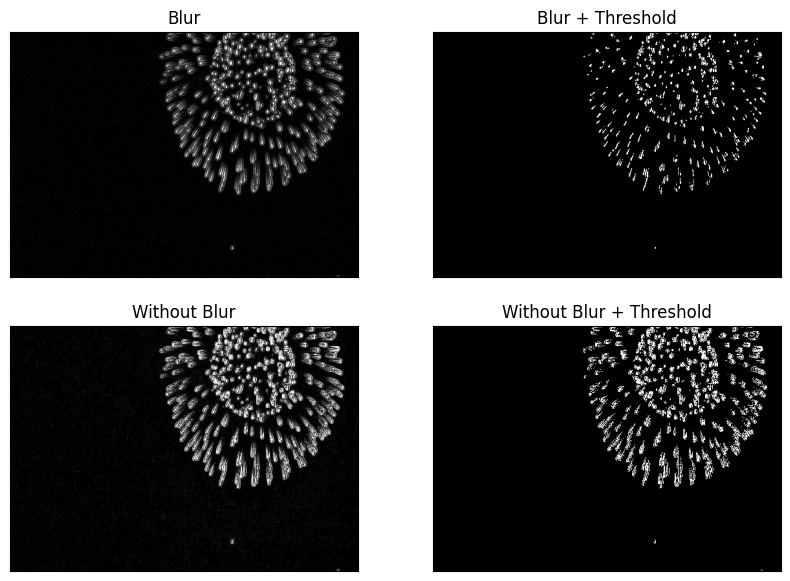

In [62]:
images = [img_blur, img_blur_threshold, 
                   img_without_blur, img_without_blur_threshold]

titles = ['Blur', 'Blur + Threshold', 'Without Blur', 'Without Blur + Threshold']
fig, axis = plt.subplots(ncols=2, nrows=2, figsize=((10, 7)))

for col in range(2):
    for row in range(2):
        axis[col][row].imshow(images[col * 2 + row], cmap='grey')
        axis[col][row].set_xticks([])
        axis[col][row].set_yticks([])
        axis[col][row].set_title(titles[col * 2 + row])

Contours

Text(0.5, 1.0, 'Contours')

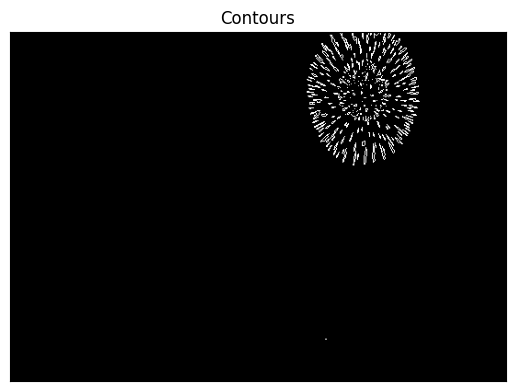

In [59]:
ret, thresh_img = cv2.threshold(gray_video_frames[100], 127, 255, cv2.THRESH_BINARY)

contours, hierarchy = cv2.findContours(thresh_img, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

img_contours = np.uint8(np.zeros((gray_video_frames.shape[1], gray_video_frames.shape[2])))

cv2.drawContours(img_contours, contours, -1, (255, 255, 255), 1)

# cv2.imshow('res', img_contours)
cv2.waitKey()
cv2.destroyAllWindows()

plt.imshow(img_contours, cmap='grey')
plt.xticks([])
plt.yticks([])
plt.title('Contours')